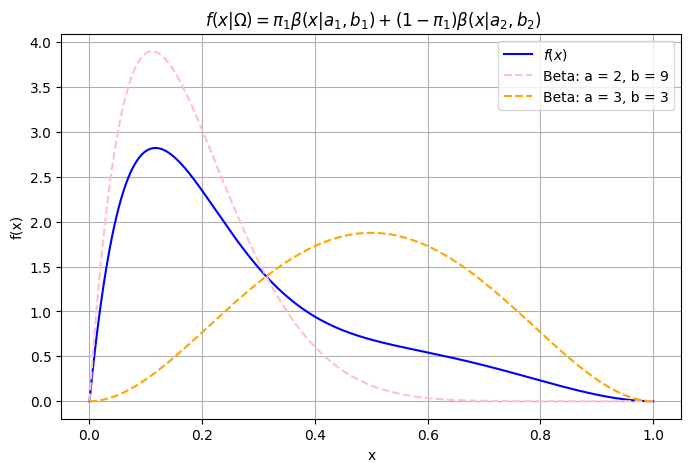

In [4]:
# draw a mixed beta distribution with beta(a1, b1) and beta(a2, b2) 
import matplotlib.pyplot as plt
import numpy as np  
from scipy.stats import beta
import scipy.stats as stats

a1, b1 = 2, 9
a2, b2 = 3, 3
f = lambda x: 0.7 * stats.beta.pdf(x, a1, b1) + 0.3 * stats.beta.pdf(x, a2, b2)
x = np.linspace(0, 1, 1000)
y = f(x)
fig = plt.figure( figsize=(8, 5))
plt.plot(x, y, label='$f(x)$', color='blue')     
plt.grid()
plt.plot( x, beta.pdf(x, a1, b1), label= f'Beta: a = {a1}, b = {b1}', color='pink', linestyle='--') 
plt.plot( x, beta.pdf(x, a2, b2), label= f'Beta: a = {a2}, b = {b2}', color='orange', linestyle='--')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title(' $f(x|\\Omega) = \\pi_1 \\beta(x|a_1,b_1) + (1 - \\pi_1) \\beta(x|a_2, b_2)$ ')
plt.legend()
plt.show()


In [18]:
import matplotlib.pyplot as plt
import numpy as np  
from scipy.stats import beta
from scipy.stats import binom
import scipy.stats as stats
a1, b1 = 2, 9
a2, b2 = 3, 3
pi1 = 0.7
n = 1000 #sample size
N = 100

params0 = [0.5, 1, 6, 2, 2] 
bnd = ((0, 1), (0, None), (0, None), (0, None), (0, None))  
opts = {'disp': False, 'maxiter': 8000, 'ftol': 1e-6}
RESULT = np.zeros((N, 5))
n1 = binom.rvs(1, pi1)
SAMPLE = np.r_[beta.rvs(a1, b1, size=(n1, N)), beta.rvs(a2, b2, size=(n-n1, N))]  
# generate random samples from the mixed beta distribution
 #number of simulations
for i in range(N):  
    x_all = SAMPLE[:, i]
    
    f= lambda x: -np.sum(np.log(x[0]* beta.pdf(x_all, x[1], x[2]) + (1-x[0]) * beta.pdf(x_all, x[3], x[4])))
    result = minimize(f, params0, method = "L-BFGS-B" , bounds=bnd, options=opts)  


RESULT[i, :] = result.x

#Evaluation

  

print(result.x)

[0.88298589 3.19478324 3.40194477 2.73305021 1.84810449]


[0.71846361 1.83733091 7.20566035 4.7392218  3.67785546]


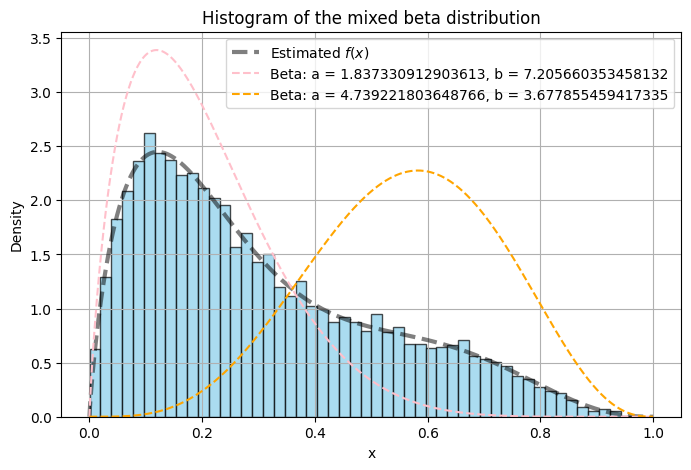

In [11]:
# compute MLE of the mixture of two beta distributions from the random samples
import numpy as np
from scipy.optimize import minimize
from scipy.stats import beta
from scipy.stats import binom
import scipy.stats as stats

# generate random samples from the mixed beta distribution
N = 10000
n1 = binom.rvs(1, pi1)
x1 = beta.rvs(a1, b1, size=int(N*pi1))
x2 = beta.rvs(a2, b2, size=N-len(x1))
x_all = np.concatenate((x1, x2))

# minimize the negative log-likelihood function 
def neg_log_likelihood(params):
    pi, a1, b1, a2, b2 = params
    return -np.sum(np.log(pi * beta.pdf(x_all, a1, b1) + (1-pi) * beta.pdf(x_all, a2, b2)))

# initial guess of the parameters
params0 = [0.5, 1, 6, 2, 2] 
bnd = ((0, 1), (0, None), (0, None), (0, None), (0, None))  
opts = {'disp': False, 'maxiter': 8000, 'ftol': 1e-6}
result = minimize(neg_log_likelihood, params0, method = "L-BFGS-B" , bounds=bnd, options=opts)  

print(result.x)

#plot the estimated distribution
pi, a1, b1, a2, b2 = result.x
f= lambda x: pi * stats.beta.pdf(x, a1, b1) + (1-pi) * stats.beta.pdf(x, a2, b2)
x = np.linspace(0, 1, 1000)
y = f(x)
fig = plt.figure( figsize=(8, 5))
plt.plot(x, y, label='Estimated $f(x)$', color='black', linewidth=3, alpha=0.5, linestyle='--') 
plt.plot( x, beta.pdf(x, a1, b1), label= f'Beta: a = {a1}, b = {b1}', color='pink', linestyle='--')
plt.plot( x, beta.pdf(x, a2, b2), label= f'Beta: a = {a2}, b = {b2}', color='orange', linestyle='--')
plt.grid()
plt.hist(x_all, bins=50, density=True, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Histogram of the mixed beta distribution')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.show()



In [20]:
import matplotlib.pyplot as plt
import numpy as np  
from scipy.stats import beta
from scipy.stats import binom
import scipy.stats as stats
a1, b1 = 2, 9
a2, b2 = 3, 3
pi1 = 0.7
n = [100, 300] #sample size
N = 100

params0 = [0.5, 1, 6, 2, 2] 
bnd = ((0, 1), (0, None), (0, None), (0, None), (0, None))  
opts = {'disp': False, 'maxiter': 8000, 'ftol': 1e-6}
for j in range(len(n)):
    RESULT = np.zeros((N, 5))
    n1 = binom.rvs(1, pi1)
    SAMPLE = np.r_[beta.rvs(a1, b1, size=(n1, N)), beta.rvs(a2, b2, size=(n[j]-n1, N))]
    
    for i in range(N):  
        x_all = SAMPLE[:, i]

        f = lambda x: -np.sum(np.log(x[0] * beta.pdf(x_all, x[1], x[2]) + (1 - x[0]) * beta.pdf(x_all, x[3], x[4])))
        result = minimize(f, params0, method="L-BFGS-B", bounds=bnd, options=opts)  

        RESULT[i, :] = result.x

#Evaluation

  

print(result.x)

[ 0.25476524  6.11305608 16.16076277  5.30638373  4.06287077]
